In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [12]:
print("Mukesh R 24BAD075")
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

print(ratings.head())
print(movies.head())


Mukesh R 24BAD075
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [3]:
data = pd.merge(ratings, movies, on='movieId')

print(data.head())

   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


In [4]:
user_item_matrix = data.pivot_table(index='userId',
                                    columns='title',
                                    values='rating')

print(user_item_matrix.head())

title   '71 (2014)  'Hellboy': The Seeds of Creation (2004)  \
userId                                                        
1              NaN                                      NaN   
2              NaN                                      NaN   
3              NaN                                      NaN   
4              NaN                                      NaN   
5              NaN                                      NaN   

title   'Round Midnight (1986)  'Salem's Lot (2004)  \
userId                                                
1                          NaN                  NaN   
2                          NaN                  NaN   
3                          NaN                  NaN   
4                          NaN                  NaN   
5                          NaN                  NaN   

title   'Til There Was You (1997)  'Tis the Season for Love (2015)  \
userId                                                               
1                             Na

In [5]:
user_item_filled = user_item_matrix.fillna(0)

SCENARIO 1 – USER-BASED CF

In [6]:
user_similarity = cosine_similarity(user_item_filled)

user_similarity_df = pd.DataFrame(user_similarity,
                                 index=user_item_matrix.index,
                                 columns=user_item_matrix.index)

In [7]:
def get_similar_users(user_id, n=5):
    similar = user_similarity_df[user_id].sort_values(ascending=False)
    return similar.iloc[1:n+1]

print(get_similar_users(1))

userId
266    0.357408
313    0.351562
368    0.345127
57     0.345034
91     0.334727
Name: 1, dtype: float64


In [8]:
def predict_rating(user_id, movie):
    similar_users = get_similar_users(user_id, 5)
    
    ratings = user_item_matrix.loc[similar_users.index, movie]
    sim_scores = similar_users.values
    
    if ratings.sum() == 0:
        return 0
    
    return np.dot(ratings.fillna(0), sim_scores) / sim_scores.sum()

In [9]:
def recommend_movies(user_id, n=5):
    user_data = user_item_matrix.loc[user_id]
    unseen_movies = user_data[user_data.isna()].index
    
    predictions = {}
    
    for movie in unseen_movies:
        predictions[movie] = predict_rating(user_id, movie)
    
    recommended = sorted(predictions.items(), key=lambda x: x[1], reverse=True)
    return recommended[:n]

print(recommend_movies(1))

[('Aliens (1986)', np.float64(4.80100193758383)), ('Hunt for Red October, The (1990)', np.float64(4.298950005529131)), ('Blade Runner (1982)', np.float64(4.004742155042099)), ('Terminator 2: Judgment Day (1991)', np.float64(4.003711070249842)), ('Die Hard (1988)', np.float64(4.0))]


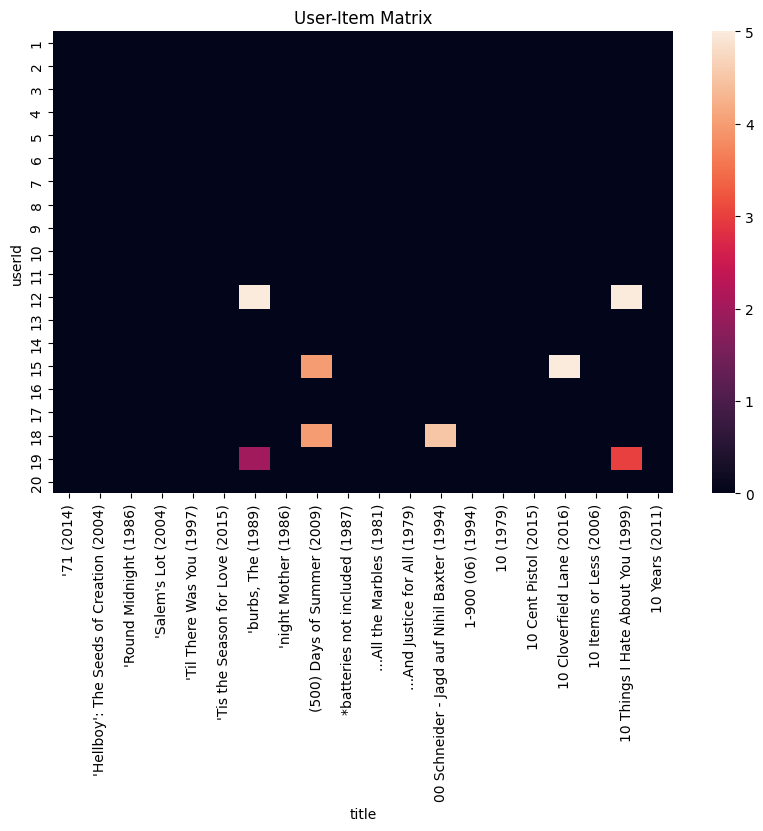

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(user_item_filled.iloc[:20,:20])
plt.title("User-Item Matrix")
plt.show()

SCENARIO 2 – ITEM-BASED CF

In [19]:
print("Mukesh R 24BAD075")
item_user_matrix = user_item_matrix.T.fillna(0)

Mukesh R 24BAD075


In [14]:
item_similarity = cosine_similarity(item_user_matrix)

item_similarity_df = pd.DataFrame(item_similarity,
                                 index=item_user_matrix.index,
                                 columns=item_user_matrix.index)

In [15]:
def get_similar_items(movie, n=5):
    similar = item_similarity_df[movie].sort_values(ascending=False)
    return similar.iloc[1:n+1]

print(get_similar_items("Toy Story (1995)"))

title
Toy Story 2 (1999)                           0.572601
Jurassic Park (1993)                         0.565637
Independence Day (a.k.a. ID4) (1996)         0.564262
Star Wars: Episode IV - A New Hope (1977)    0.557388
Forrest Gump (1994)                          0.547096
Name: Toy Story (1995), dtype: float64


In [16]:
def recommend_items(user_id, n=5):
    user_ratings = user_item_matrix.loc[user_id]
    liked_movies = user_ratings[user_ratings >= 4].index
    
    scores = {}
    
    for movie in liked_movies:
        similar_movies = get_similar_items(movie)
        for sim_movie, score in similar_movies.items():
            scores[sim_movie] = scores.get(sim_movie, 0) + score
    
    recommended = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return recommended[:n]

print(recommend_items(1))

[('Indiana Jones and the Temple of Doom (1984)', 10.340599418417032), ('Reservoir Dogs (1992)', 10.277447284285445), ('RoboCop (1987)', 8.974865970976703), ('Star Wars: Episode V - The Empire Strikes Back (1980)', 8.123595972936831), ("Ferris Bueller's Day Off (1986)", 6.226053115904851)]


In [17]:
actual = []
predicted = []

for user in user_item_matrix.index[:50]:
    for movie in user_item_matrix.columns[:50]:
        if not np.isnan(user_item_matrix.loc[user, movie]):
            pred = predict_rating(user, movie)
            actual.append(user_item_matrix.loc[user, movie])
            predicted.append(pred)

print("RMSE:", np.sqrt(mean_squared_error(actual, predicted)))
print("MAE:", mean_absolute_error(actual, predicted))

RMSE: 2.672443488845602
MAE: 2.2746512371243446
